In [54]:
import pandas as pd
import numpy as np
import seaborn as sns

In [55]:
df=pd.read_csv('data/BHP.csv')

In [56]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


<Axes: >

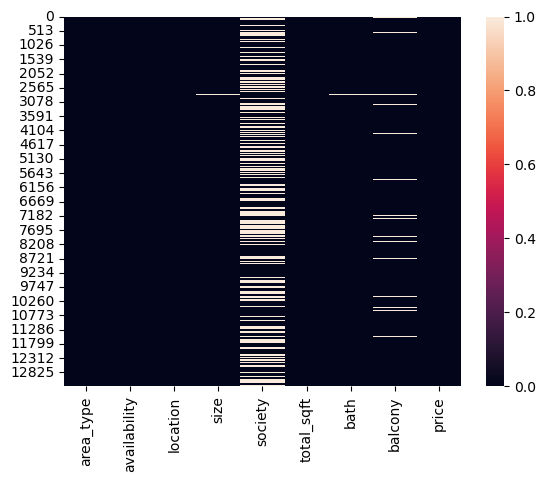

In [57]:
sns.heatmap(df.isnull())

In [58]:
df=df.drop(['availability','balcony','society'],axis=1)

In [59]:
df.head()

,area_type,location,size,total_sqft,bath,price
0,Super built-up Area,Electronic City Phase II,2 BHK,1056,2.0,39.07
1,Plot Area,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00
2,Built-up Area,Uttarahalli,3 BHK,1440,2.0,62.00
3,Super built-up Area,Lingadheeranahalli,3 BHK,1521,3.0,95.00
4,Super built-up Area,Kothanur,2 BHK,1200,2.0,51.00


In [60]:
median_per_group = df.groupby('area_type')['bath'].transform('median')
df['bath'] = df['bath'].fillna(median_per_group)


In [61]:
df.isnull().sum()

area_type      0
location       1
size          16
total_sqft     0
bath           0
price          0
dtype: int64

In [62]:
df=df.dropna()
df.shape

(13303, 6)

In [63]:
df['size']=df['size'].apply(lambda x: int(x.split(' ')[0]))

In [64]:
df

,area_type,location,size,total_sqft,bath,price
0,Super built-up Area,Electronic City Phase II,2,1056,2.0,39.07
1,Plot Area,Chikka Tirupathi,4,2600,5.0,120.00
2,Built-up Area,Uttarahalli,3,1440,2.0,62.00
3,Super built-up Area,Lingadheeranahalli,3,1521,3.0,95.00
4,Super built-up Area,Kothanur,2,1200,2.0,51.00
...,...,...,...,...,...,...
13315,Built-up Area,Whitefield,5,3453,4.0,231.00
13316,Super built-up Area,Richards Town,4,3600,5.0,400.00
13317,Built-up Area,Raja Rajeshwari Nagar,2,1141,2.0,60.00
13318,Super built-up Area,Padmanabhanagar,4,4689,4.0,488.00


In [65]:
df['total_sqft'].unique()

array(['1056', '2600', '1440', ..., '1133 - 1384', '774', '4689'],
      dtype=object)

In [66]:
def isfloat(x):
    try:
        float(x)
    except:
        return False
    return True

In [67]:
df[~df['total_sqft'].apply(isfloat)]

,area_type,location,size,total_sqft,bath,price
30,Super built-up Area,Yelahanka,4,2100 - 2850,4.0,186.000
56,Built-up Area,Devanahalli,4,3010 - 3410,2.0,192.000
81,Built-up Area,Hennur Road,4,2957 - 3450,2.0,224.500
122,Super built-up Area,Hebbal,4,3067 - 8156,4.0,477.000
137,Super built-up Area,8th Phase JP Nagar,2,1042 - 1105,2.0,54.005
...,...,...,...,...,...,...
12990,Super built-up Area,Talaghattapura,3,1804 - 2273,3.0,122.000
13059,Super built-up Area,Harlur,2,1200 - 1470,2.0,72.760
13240,Super built-up Area,Devanahalli,1,1020 - 1130,2.0,52.570
13265,Super built-up Area,Hoodi,2,1133 - 1384,2.0,59.135


In [68]:
df[~df['total_sqft'].apply(isfloat)]['total_sqft'].unique()

array(['2100 - 2850', '3010 - 3410', '2957 - 3450', '3067 - 8156',
       '1042 - 1105', '1145 - 1340', '1015 - 1540', '1520 - 1740',
       '34.46Sq. Meter', '1195 - 1440', '4125Perch', '1120 - 1145',
       '4400 - 6640', '3090 - 5002', '4400 - 6800', '1160 - 1195',
       '1000Sq. Meter', '4000 - 5249', '1115 - 1130', '1100Sq. Yards',
       '520 - 645', '1000 - 1285', '3606 - 5091', '650 - 665',
       '633 - 666', '5.31Acres', '30Acres', '1445 - 1455', '884 - 1116',
       '850 - 1093', '1440 - 1884', '716Sq. Meter', '547.34 - 827.31',
       '580 - 650', '3425 - 3435', '1804 - 2273', '3630 - 3800',
       '660 - 670', '1500Sq. Meter', '620 - 933', '142.61Sq. Meter',
       '2695 - 2940', '1574Sq. Yards', '3450 - 3472', '1250 - 1305',
       '670 - 980', '1005.03 - 1252.49', '1004 - 1204', '361.33Sq. Yards',
       '645 - 936', '2710 - 3360', '2249.81 - 4112.19', '3436 - 3643',
       '2830 - 2882', '596 - 804', '1255 - 1863', '1300 - 1405',
       '117Sq. Yards', '934 - 1437', '9

In [69]:
def rangetofloat(x):
  
    if len(x.split('-'))==2:
        a=x.split('-')
        return (float(a[0])+float(a[1]))/2
    elif len(x.split('Sq.'))==2:
        a=x.split('Sq.')
        if(a[1].strip()=='Yards'):
            return float(a[0])*9
        elif a[1].strip()=='Meter':
            return float(a[0])*10.73
    elif len(x.split('Acr'))==2:
        return float(x.split('Acr')[0])*43500
    elif len(x.split('Gun'))==2:
        return float(x.split('Gun')[0])*1089
    elif len(x.split('Gr'))==2:
        return float(x.split('Gr')[0])*2400
    elif len(x.split('Pe'))==2:
        return float(x.split('Pe')[0])*272.25
    elif len(x.split('Ce'))==2:
        return float(x.split('Ce')[0])*435.6
    try:
        return float(x)
    except:
        return None

In [70]:
rangetofloat('216')

216.0

In [71]:
df['total_sqft']=df['total_sqft'].apply(rangetofloat)


In [72]:
df['total_sqft'].dtype

dtype('float64')

In [73]:
df

,area_type,location,size,total_sqft,bath,price
0,Super built-up Area,Electronic City Phase II,2,1056.0,2.0,39.07
1,Plot Area,Chikka Tirupathi,4,2600.0,5.0,120.00
2,Built-up Area,Uttarahalli,3,1440.0,2.0,62.00
3,Super built-up Area,Lingadheeranahalli,3,1521.0,3.0,95.00
4,Super built-up Area,Kothanur,2,1200.0,2.0,51.00
...,...,...,...,...,...,...
13315,Built-up Area,Whitefield,5,3453.0,4.0,231.00
13316,Super built-up Area,Richards Town,4,3600.0,5.0,400.00
13317,Built-up Area,Raja Rajeshwari Nagar,2,1141.0,2.0,60.00
13318,Super built-up Area,Padmanabhanagar,4,4689.0,4.0,488.00


In [74]:
df['total_sqft'].unique()

array([1056. , 2600. , 1440. , ..., 1258.5,  774. , 4689. ])

In [75]:
df['location'].unique()

array(['Electronic City Phase II', 'Chikka Tirupathi', 'Uttarahalli', ...,
       '12th cross srinivas nagar banshankari 3rd stage',
       'Havanur extension', 'Abshot Layout'], dtype=object)

<Axes: xlabel='size', ylabel='total_sqft'>

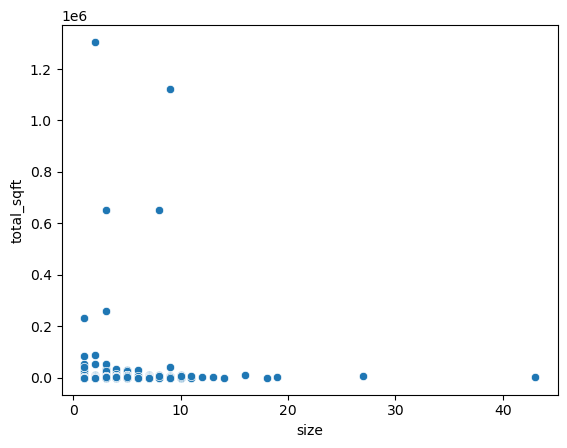

In [76]:
sns.scatterplot(x='size',y='total_sqft',data=df)

<Axes: xlabel='size', ylabel='Count'>

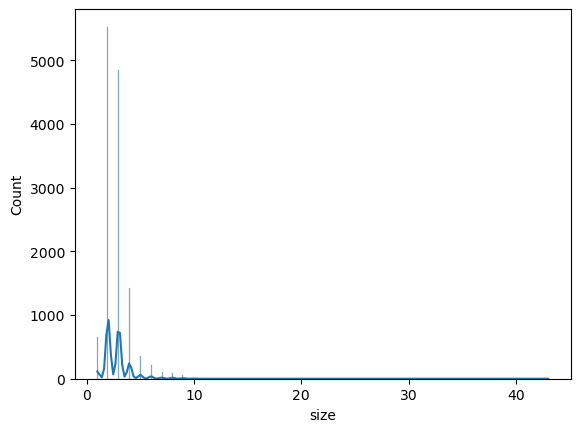

In [77]:
sns.histplot(x='size',data=df,kde=True)

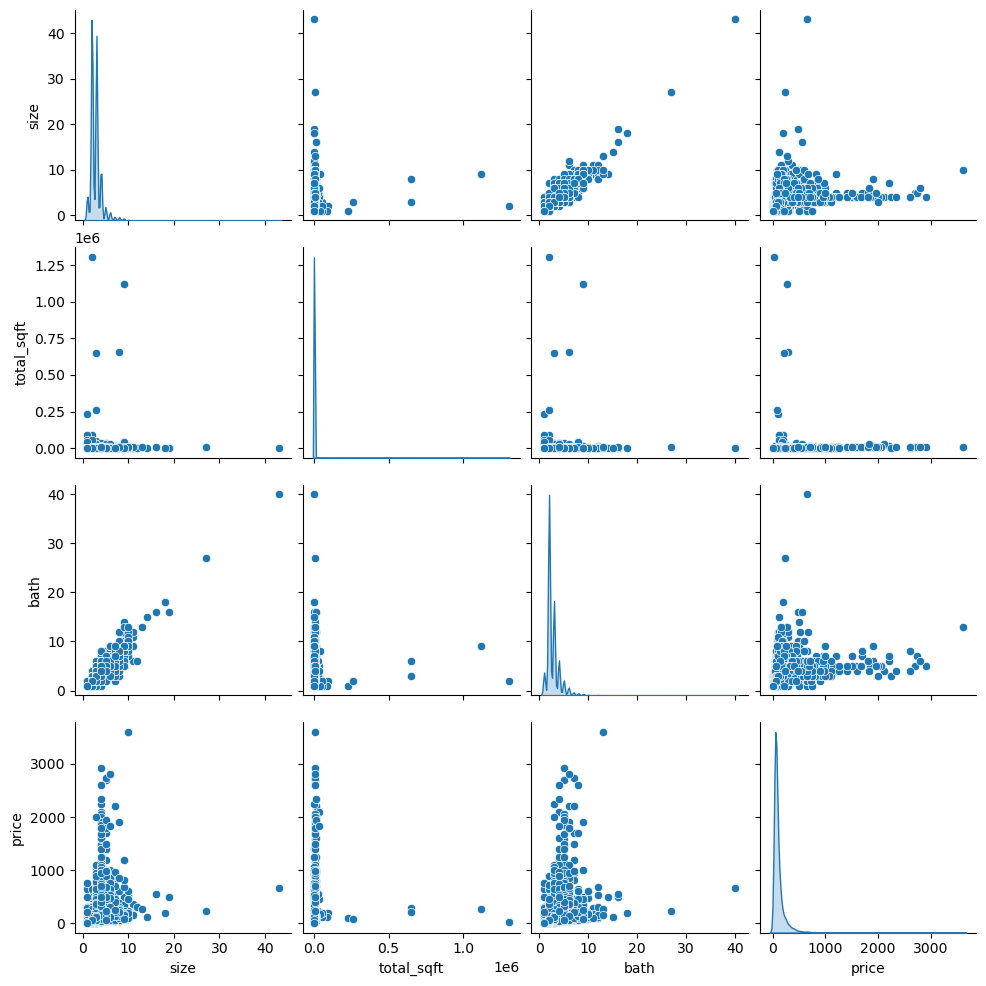

In [78]:
sns.pairplot(df,diag_kind='kde')

In [79]:
temp=df['size'].quantile(0.995)
temp

9.0

In [80]:
df['sqft/bhk']=df['total_sqft']/df['size']

In [81]:
df

,area_type,location,size,total_sqft,bath,price,sqft/bhk
0,Super built-up Area,Electronic City Phase II,2,1056.0,2.0,39.07,528.00
1,Plot Area,Chikka Tirupathi,4,2600.0,5.0,120.00,650.00
2,Built-up Area,Uttarahalli,3,1440.0,2.0,62.00,480.00
3,Super built-up Area,Lingadheeranahalli,3,1521.0,3.0,95.00,507.00
4,Super built-up Area,Kothanur,2,1200.0,2.0,51.00,600.00
...,...,...,...,...,...,...,...
13315,Built-up Area,Whitefield,5,3453.0,4.0,231.00,690.60
13316,Super built-up Area,Richards Town,4,3600.0,5.0,400.00,900.00
13317,Built-up Area,Raja Rajeshwari Nagar,2,1141.0,2.0,60.00,570.50
13318,Super built-up Area,Padmanabhanagar,4,4689.0,4.0,488.00,1172.25


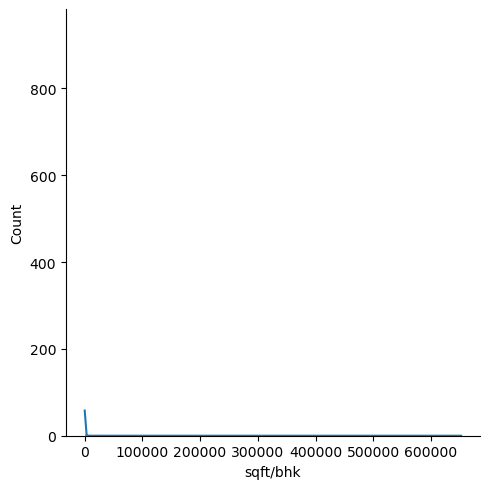

In [83]:
sns.displot(df['sqft/bhk'],kde=True,)

In [84]:
df['sqft/bhk'].max()

652500.0

In [85]:
df['sqft/bhk'].min()

0.25

In [86]:
df['sqft/bhk'].mean()

701.6463469070047

In [87]:
df['sqft/bhk'].median()

552.5

In [88]:
df['sqft/bhk'].quantile(0.99)

1400.0

In [89]:
df['sqft/bhk'].quantile(0.01)

140.0

In [90]:
#Remove all rows that are outliers in this ratio using quantile
df1=df[(df['sqft/bhk']<=df['sqft/bhk'].quantile(0.99)) & (df['sqft/bhk']>=df['sqft/bhk'].quantile(0.01))]



In [91]:

df1

,area_type,location,size,total_sqft,bath,price,sqft/bhk
0,Super built-up Area,Electronic City Phase II,2,1056.0,2.0,39.07,528.00
1,Plot Area,Chikka Tirupathi,4,2600.0,5.0,120.00,650.00
2,Built-up Area,Uttarahalli,3,1440.0,2.0,62.00,480.00
3,Super built-up Area,Lingadheeranahalli,3,1521.0,3.0,95.00,507.00
4,Super built-up Area,Kothanur,2,1200.0,2.0,51.00,600.00
...,...,...,...,...,...,...,...
13315,Built-up Area,Whitefield,5,3453.0,4.0,231.00,690.60
13316,Super built-up Area,Richards Town,4,3600.0,5.0,400.00,900.00
13317,Built-up Area,Raja Rajeshwari Nagar,2,1141.0,2.0,60.00,570.50
13318,Super built-up Area,Padmanabhanagar,4,4689.0,4.0,488.00,1172.25


In [92]:
df

,area_type,location,size,total_sqft,bath,price,sqft/bhk
0,Super built-up Area,Electronic City Phase II,2,1056.0,2.0,39.07,528.00
1,Plot Area,Chikka Tirupathi,4,2600.0,5.0,120.00,650.00
2,Built-up Area,Uttarahalli,3,1440.0,2.0,62.00,480.00
3,Super built-up Area,Lingadheeranahalli,3,1521.0,3.0,95.00,507.00
4,Super built-up Area,Kothanur,2,1200.0,2.0,51.00,600.00
...,...,...,...,...,...,...,...
13315,Built-up Area,Whitefield,5,3453.0,4.0,231.00,690.60
13316,Super built-up Area,Richards Town,4,3600.0,5.0,400.00,900.00
13317,Built-up Area,Raja Rajeshwari Nagar,2,1141.0,2.0,60.00,570.50
13318,Super built-up Area,Padmanabhanagar,4,4689.0,4.0,488.00,1172.25


<Axes: xlabel='size', ylabel='total_sqft'>

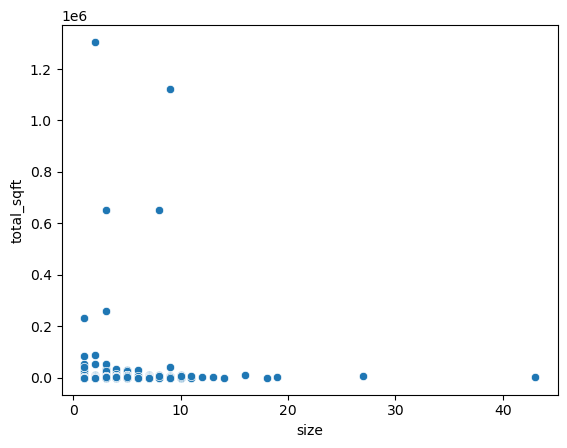

In [93]:
sns.scatterplot(x='size',y='total_sqft',data=df)

<Axes: xlabel='size', ylabel='total_sqft'>

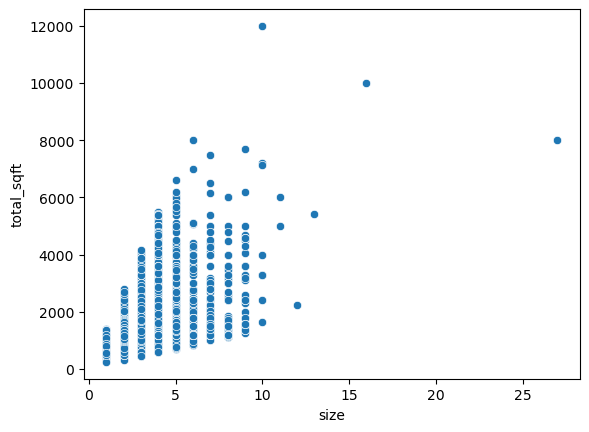

In [94]:
sns.scatterplot(x='size',y='total_sqft',data=df1)

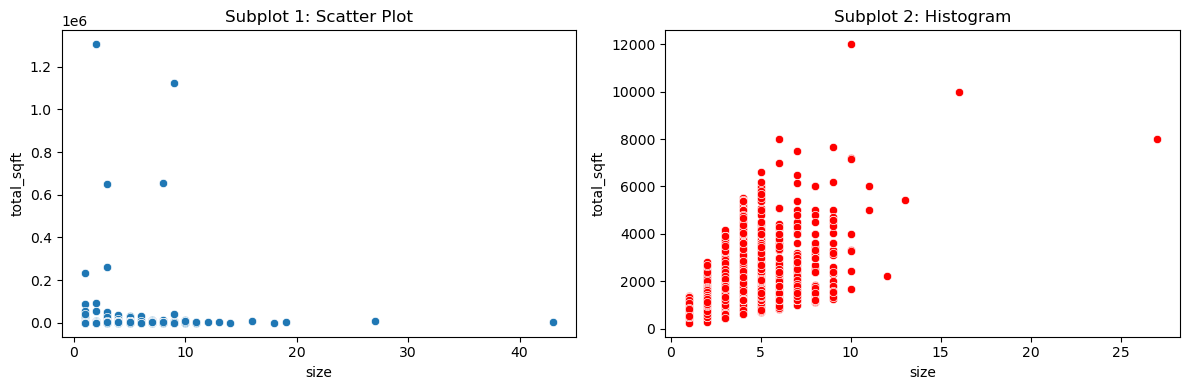

In [96]:
# Create a figure with subplots
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 4))


sns.scatterplot(x='size', y='total_sqft',data=df, ax=axes[0])
axes[0].set_title('Subplot 1: Scatter Plot')


sns.scatterplot(data=df1,x='size',y='total_sqft', color='red', ax=axes[1])
axes[1].set_title('Subplot 2: Histogram')

# Adjust spacing between subplots
plt.tight_layout()

In [122]:
df1

,area_type,location,size,total_sqft,bath,price,sqft/bhk
0,Super built-up Area,Electronic City Phase II,2,1056.0,2.0,39.07,528.00
1,Plot Area,Chikka Tirupathi,4,2600.0,5.0,120.00,650.00
2,Built-up Area,Uttarahalli,3,1440.0,2.0,62.00,480.00
3,Super built-up Area,Lingadheeranahalli,3,1521.0,3.0,95.00,507.00
4,Super built-up Area,Kothanur,2,1200.0,2.0,51.00,600.00
...,...,...,...,...,...,...,...
13315,Built-up Area,Whitefield,5,3453.0,4.0,231.00,690.60
13316,Super built-up Area,Richards Town,4,3600.0,5.0,400.00,900.00
13317,Built-up Area,Raja Rajeshwari Nagar,2,1141.0,2.0,60.00,570.50
13318,Super built-up Area,Padmanabhanagar,4,4689.0,4.0,488.00,1172.25


In [126]:
# Find price per sqft
df1['price_per_sqft']=df1['price']/df['total_sqft']*100000

C:\Users\sagni\AppData\Local\Temp\ipykernel_14100\3793661759.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['price_per_sqft']=df1['price']/df['total_sqft']*100000


In [127]:
df1

,area_type,location,size,total_sqft,bath,price,sqft/bhk,price_per_sqft
0,Super built-up Area,Electronic City Phase II,2,1056.0,2.0,39.07,528.00,3699.810606
1,Plot Area,Chikka Tirupathi,4,2600.0,5.0,120.00,650.00,4615.384615
2,Built-up Area,Uttarahalli,3,1440.0,2.0,62.00,480.00,4305.555556
3,Super built-up Area,Lingadheeranahalli,3,1521.0,3.0,95.00,507.00,6245.890861
4,Super built-up Area,Kothanur,2,1200.0,2.0,51.00,600.00,4250.000000
...,...,...,...,...,...,...,...,...
13315,Built-up Area,Whitefield,5,3453.0,4.0,231.00,690.60,6689.834926
13316,Super built-up Area,Richards Town,4,3600.0,5.0,400.00,900.00,11111.111111
13317,Built-up Area,Raja Rajeshwari Nagar,2,1141.0,2.0,60.00,570.50,5258.545136
13318,Super built-up Area,Padmanabhanagar,4,4689.0,4.0,488.00,1172.25,10407.336319


In [128]:
df1['price_per_sqft'].isnull().sum()

0

In [129]:
#Analysing Location
df1['location'].unique()

array(['Electronic City Phase II', 'Chikka Tirupathi', 'Uttarahalli', ...,
       'Tilak Nagar', 'Havanur extension', 'Abshot Layout'], dtype=object)

In [130]:
df1['location'].nunique()
#Too many unique location. High Dimensionality problem.

1268

In [140]:
# Reducing Dimensionality using Grouping
df2=df1.copy()
df2.location=df2.location.apply(lambda x: x.strip())
a=df2.groupby('location')['location'].agg('count').sort_values(ascending=False)
list_location=list(a)
a


location
Whitefield                     531
Sarjapur  Road                 392
Electronic City                303
Kanakpura Road                 271
Thanisandra                    237
                              ... 
Kanakapura Road,                 1
1 Immadihalli                    1
Karnataka Shabarimala            1
Kasthuri Nagar East Of NGEF      1
whitefiled                       1
Name: location, Length: 1258, dtype: int64

In [142]:
#Now we will aggregate places with low occurance into a single group
#Counting places with low occurance
s=0
for i in list_location:
    if i<=10:
        s+=1
s

1020

In [144]:
location_less_than10=a[a<=10]
location_less_than10 #Slicing the series

location
Kalkere                        10
Naganathapura                  10
Dairy Circle                   10
Nagappa Reddy Layout           10
Nagadevanahalli                10
                               ..
Kanakapura Road,                1
1 Immadihalli                   1
Karnataka Shabarimala           1
Kasthuri Nagar East Of NGEF     1
whitefiled                      1
Name: location, Length: 1020, dtype: int64

In [147]:
df2.location=df2.location.apply(lambda x: 'other' if x in location_less_than10 else x)
df2['location'].unique()

array(['Electronic City Phase II', 'Chikka Tirupathi', 'Uttarahalli',
       'Lingadheeranahalli', 'Kothanur', 'Whitefield', 'Old Airport Road',
       'Rajaji Nagar', 'Marathahalli', 'other', '7th Phase JP Nagar',
       'Gottigere', 'Sarjapur', 'Mysore Road', 'Bisuvanahalli',
       'Raja Rajeshwari Nagar', 'Kengeri', 'Binny Pete', 'Thanisandra',
       'Bellandur', 'Electronic City', 'Ramagondanahalli', 'Yelahanka',
       'Hebbal', 'Kasturi Nagar', 'Kanakpura Road',
       'Electronics City Phase 1', 'Kundalahalli', 'Chikkalasandra',
       'Murugeshpalya', 'Sarjapur  Road', 'Doddathoguru', 'KR Puram',
       'Bhoganhalli', 'Lakshminarayana Pura', 'Begur Road', 'Devanahalli',
       'Varthur', 'Bommanahalli', 'Gunjur', 'Devarachikkanahalli',
       'Hegde Nagar', 'Haralur Road', 'Hennur Road', 'Kothannur',
       'Kalena Agrahara', 'Kaval Byrasandra', 'ISRO Layout',
       'Garudachar Palya', 'EPIP Zone', 'Dasanapura', 'Kasavanhalli',
       'Sanjay nagar', 'Domlur', 'Sarjapura - A

In [148]:
df2['location'].nunique()

239

In [149]:
df2

,area_type,location,size,total_sqft,bath,price,sqft/bhk,price_per_sqft
0,Super built-up Area,Electronic City Phase II,2,1056.0,2.0,39.07,528.00,3699.810606
1,Plot Area,Chikka Tirupathi,4,2600.0,5.0,120.00,650.00,4615.384615
2,Built-up Area,Uttarahalli,3,1440.0,2.0,62.00,480.00,4305.555556
3,Super built-up Area,Lingadheeranahalli,3,1521.0,3.0,95.00,507.00,6245.890861
4,Super built-up Area,Kothanur,2,1200.0,2.0,51.00,600.00,4250.000000
...,...,...,...,...,...,...,...,...
13315,Built-up Area,Whitefield,5,3453.0,4.0,231.00,690.60,6689.834926
13316,Super built-up Area,other,4,3600.0,5.0,400.00,900.00,11111.111111
13317,Built-up Area,Raja Rajeshwari Nagar,2,1141.0,2.0,60.00,570.50,5258.545136
13318,Super built-up Area,Padmanabhanagar,4,4689.0,4.0,488.00,1172.25,10407.336319


In [150]:
# Furthur outlier removal, We already used cutoff on 99 percentile
df2[df2['sqft/bhk']<300]
# These are anomalies that an be removed

,area_type,location,size,total_sqft,bath,price,sqft/bhk,price_per_sqft
9,Plot Area,other,6,1020.0,6.0,370.0,170.000000,36274.509804
58,Plot Area,Murugeshpalya,6,1407.0,4.0,150.0,234.500000,10660.980810
68,Plot Area,Devarachikkanahalli,8,1350.0,7.0,85.0,168.750000,6296.296296
70,Plot Area,other,3,500.0,3.0,100.0,166.666667,20000.000000
78,Built-up Area,Kaval Byrasandra,2,460.0,1.0,22.0,230.000000,4782.608696
...,...,...,...,...,...,...,...,...
13277,Plot Area,other,7,1400.0,7.0,218.0,200.000000,15571.428571
13279,Plot Area,other,6,1200.0,5.0,130.0,200.000000,10833.333333
13281,Plot Area,Margondanahalli,5,1375.0,5.0,125.0,275.000000,9090.909091
13303,Plot Area,Vidyaranyapura,5,774.0,5.0,70.0,154.800000,9043.927649


In [154]:
df3=df2[~(df2['sqft/bhk']<300)]
df3.shape

(12422, 8)

In [155]:
df2.shape

(13038, 8)

In [156]:
# Now looking at price per sqft
df3['price_per_sqft'].describe() # It is sensible to remove extremities based on standard deviation from mean

count     12422.000000
mean       6264.421429
std        4080.857039
min         500.000000
25%        4210.526316
50%        5285.891969
75%        6893.069386
max      176470.588235
Name: price_per_sqft, dtype: float64

C:\Users\sagni\AppData\Local\Temp\ipykernel_14100\1889813821.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df3['price_per_sqft'])


<Axes: xlabel='price_per_sqft', ylabel='Density'>

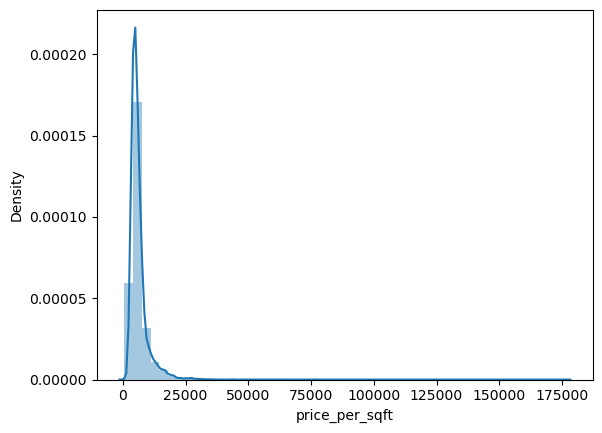

In [158]:
sns.distplot(df3['price_per_sqft'])

In [165]:
# This gives proof of skewed normal distribution with huge amount of outliers on the higher side. We normalise this with location
# Keeping data present in 1 standard deviation from mean( Around 68%)
def outlier_removal(df):
    df_out=pd.DataFrame()
    for key, subdf in df.groupby('location'):
        mean=subdf['price_per_sqft'].mean()
        std=subdf['price_per_sqft'].std()
        reduced_df=subdf[(subdf['price_per_sqft']>(mean-std)) & (subdf['price_per_sqft']<(mean+std))]
        df_out=pd.concat([df_out,reduced_df],ignore_index=True)
    return df_out
df4=outlier_removal(df3)

In [167]:
df4.shape

(10283, 8)

In [168]:
df3.shape

(12422, 8)

In [172]:
a=df4.groupby('location')['location'].agg('count').sort_values(ascending=False)
a[a>30]

location
other                 2283
Whitefield             484
Sarjapur  Road         296
Electronic City        279
Kanakpura Road         196
                      ... 
9th Phase JP Nagar      33
Kadugodi                32
Panathur                31
Horamavu Agara          31
Sahakara Nagar          31
Name: location, Length: 75, dtype: int64

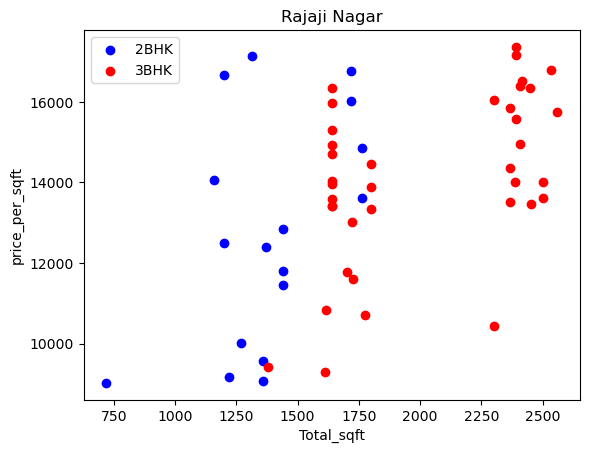

In [169]:
# Next Assumption is that for same sqft area, more number of bedrooms reduce the cost. Reason can be location, special amenities
# Visualisation
def plot_scatter(df,location):
    bhk2=df[(df.location==location) & (df['size']==2)]
    bhk3=df[(df.location==location) & (df['size']==3)]
    plt.scatter(bhk2.total_sqft,bhk2.price_per_sqft,color='b',label='2BHK')
    plt.scatter(bhk3.total_sqft,bhk3.price_per_sqft,color='r',label='3BHK')
    plt.xlabel('Total_sqft')
    plt.ylabel('price_per_sqft')
    plt.title(location)
    plt.legend()
plot_scatter(df4,'Rajaji Nagar')

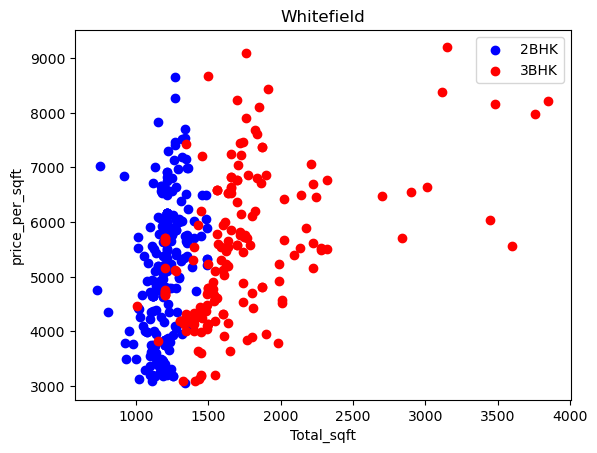

In [173]:
plot_scatter(df4,'Whitefield')

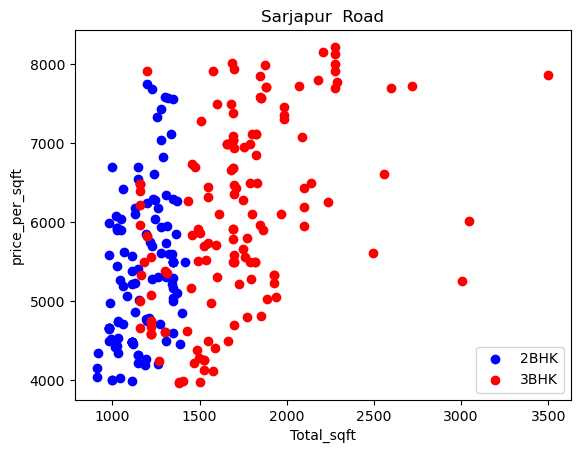

In [177]:
plot_scatter(df4,'Sarjapur  Road')

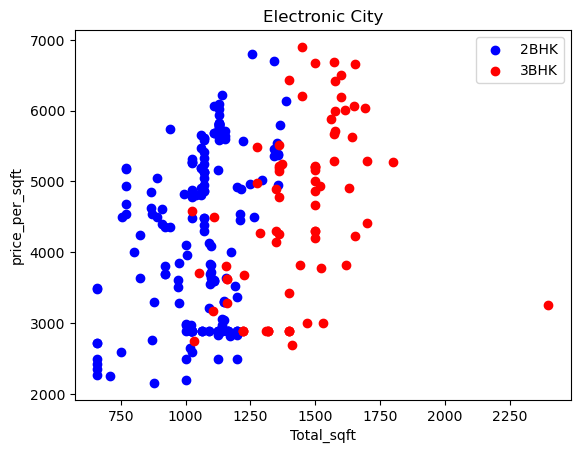

In [178]:
plot_scatter(df4,'Electronic City')

In [190]:
# So now we want to remove the occurences where for same sqft area lower number of bhk is having more price. 
# Method - If price of a 2BHK room is less than mean of all 1BHK room with same sqft area , we will drop the row
def remove_bhk_outliers(df):
    dropped_rows=np.array([])
    for location,location_df in df.groupby('location'):
        bhk_stats={}
        for bhk,bhk_df in location_df.groupby('size'):
            bhk_stats[bhk]={
                'mean':bhk_df['price_per_sqft'].mean(),
                'std':bhk_df['price_per_sqft'].std(),
                'count':bhk_df.shape[0]
            }
        for bhk,bhk_df in location_df.groupby('size'):
            stats=bhk_stats.get(bhk-1)
            if stats and stats['count']>5:
                dropped_rows=np.append(dropped_rows,bhk_df[bhk_df['price_per_sqft']<(stats['mean'])].index.values)
    return df.drop(dropped_rows,axis='index')
df5=remove_bhk_outliers(df4)
df5.shape

(7312, 8)

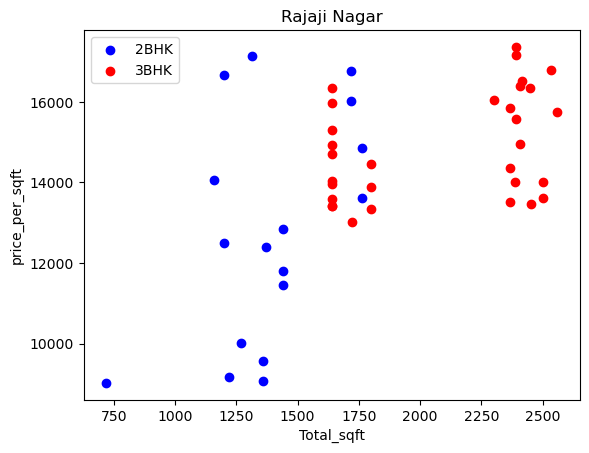

In [191]:
plot_scatter(df5,'Rajaji Nagar')

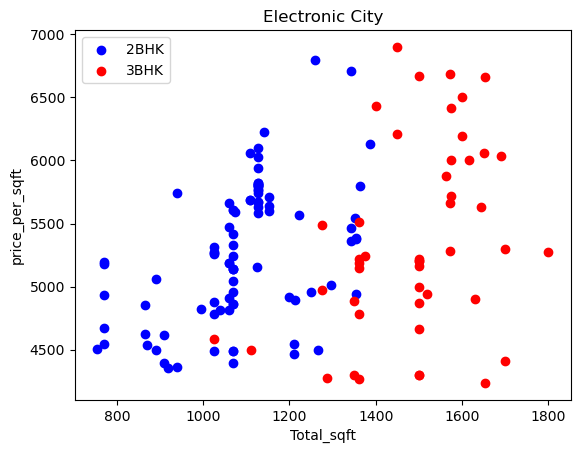

In [193]:
plot_scatter(df5,'Electronic City')

<Axes: xlabel='price_per_sqft', ylabel='Count'>

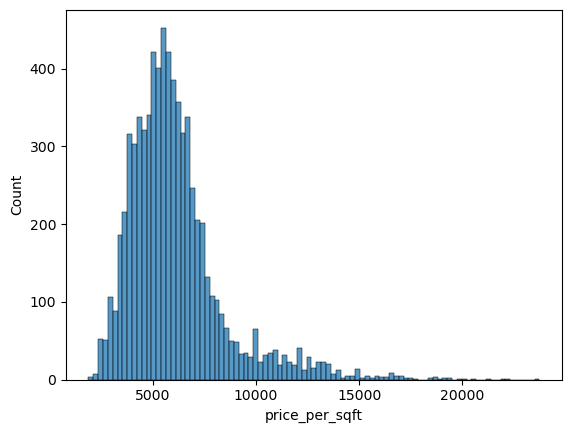

In [194]:
sns.histplot(df5.price_per_sqft)

<Axes: xlabel='price_per_sqft', ylabel='Count'>

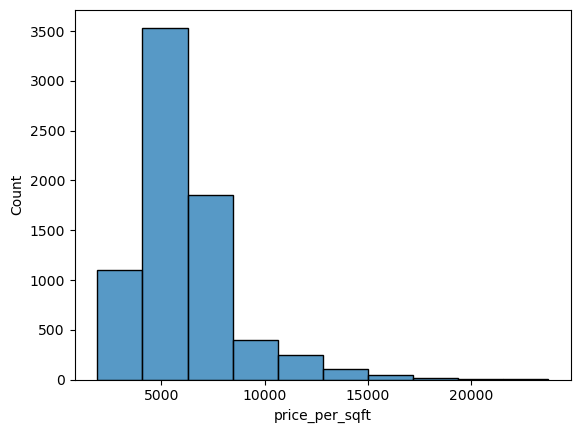

In [207]:
sns.histplot(df5.price_per_sqft,bins=10)

In [205]:
df5.bath.unique()

array([ 4.,  3.,  2.,  5.,  1.,  8.,  6.,  7.,  9., 12., 16., 13.])

<Axes: xlabel='bath', ylabel='Count'>

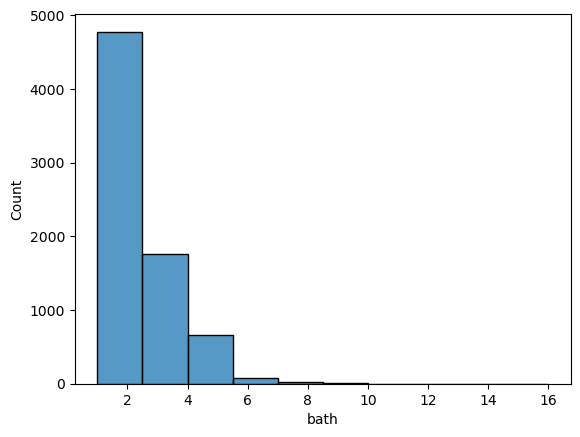

In [210]:
#Remove all rows where no of bathrooms are more than no of BHK
sns.histplot(df5.bath,bins=10)
#This shows presence of some more outliers

In [212]:
df5[df5['bath']>df5['size']+2]

,area_type,location,size,total_sqft,bath,price,sqft/bhk,price_per_sqft
1643,Built-up Area,Chikkabanavar,4,2460.0,7.0,80.0,615.0,3252.03252
6770,Super built-up Area,Thanisandra,3,1806.0,6.0,116.0,602.0,6423.03433


In [214]:
df6=df5[~(df5['bath']>df5['size']+2)]
df6.shape

(7310, 8)

In [219]:
train1=pd.get_dummies(df6,columns=['area_type','location'],drop_first=True)
train1

,size,total_sqft,bath,price,sqft/bhk,price_per_sqft,area_type_Carpet Area,area_type_Plot Area,area_type_Super built-up Area,location_1st Phase JP Nagar,...,location_Vijayanagar,location_Vishveshwarya Layout,location_Vittasandra,location_Whitefield,location_Yelachenahalli,location_Yelahanka,location_Yelahanka New Town,location_Yelenahalli,location_Yeshwanthpur,location_other
0,4,2850.0,4.0,428.0,712.500000,15017.543860,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
1,3,1630.0,3.0,194.0,543.333333,11901.840491,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
2,3,1875.0,2.0,235.0,625.000000,12533.333333,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
3,3,1200.0,2.0,130.0,400.000000,10833.333333,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,2,1235.0,2.0,148.0,617.500000,11983.805668,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10273,2,1155.0,2.0,64.0,577.500000,5541.125541,False,False,True,False,...,False,False,False,False,False,False,False,False,False,True
10275,2,1200.0,2.0,70.0,600.000000,5833.333333,True,False,False,False,...,False,False,False,False,False,False,False,False,False,True
10278,2,1353.0,2.0,110.0,676.500000,8130.081301,False,False,True,False,...,False,False,False,False,False,False,False,False,False,True
10279,1,812.0,1.0,26.0,812.000000,3201.970443,False,True,False,False,...,False,False,False,False,False,False,False,False,False,True


In [224]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(train.drop('price',axis=1),train['price'],test_size=0.3)

In [227]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)
model.score(x_test,y_test)

0.9474402950965395

In [228]:
from sklearn.ensemble import RandomForestRegressor
model1=RandomForestRegressor()
model1.fit(x_train,y_train)
model1.score(x_test,y_test)

0.9823719654983232

In [229]:
from sklearn.svm import SVR
model2=SVR()
model2.fit(x_train,y_train)
model2.score(x_test,y_test)

0.7532277208394582

In [230]:
#Using Cross Validation
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import cross_val_score
cv=ShuffleSplit(n_splits=5,test_size=0.2,random_state=42)
cross_val_score(RandomForestRegressor(),train.drop('price',axis=1),train['price'],cv=cv)

array([0.99504336, 0.99129606, 0.97549864, 0.9678797 , 0.97638643])

In [235]:
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

def gridsearch(x, y):
    algorithms = {
        'linear regression': {
            'model': LinearRegression(),
            'params': {
                
            }
        },
        'lasso': {
            'model': Lasso(),
            'params': {
                'alpha': [1, 2],
                'selection': ['random', 'cyclic']
            }
        },
        'decision tree': {
            'model': DecisionTreeRegressor(),
            'params': {
                'criterion': ['squared_error', 'friedman_mse'],
                'splitter': ['best', 'random']
            }
        },
        'random forest': {
            'model': RandomForestRegressor(),
            'params': {
                'n_estimators': [100, 200, 300],
                'max_depth': [None, 10, 20],
                'min_samples_split': [2, 5, 10],
                'min_samples_leaf': [1, 2, 4]
            }
        }
    }
    scores=[]
    cv=ShuffleSplit(n_splits=5,test_size=0.2,random_state=42)
    for algo_name,config in algorithms.items():
        gs=GridSearchCV(config['model'],config['params'],cv=cv,return_train_score=False)
        gs.fit(x,y)
        scores.append({
            'model':algo_name,
            'best score': gs.best_score_,
            'best params': gs.best_params_})

    return pd.DataFrame(scores,columns=['model','best score','best params'])
        
    
gridsearch(train.drop('price',axis=1),train['price'])
            
    
        

KeyboardInterrupt: 

In [236]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [247]:
import tensorflow as tf
model4 = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(3, activation='relu'),
    tf.keras.layers.Dense(1, activation='linear')
])

In [248]:


model4.compile(optimizer='adam', loss='mse')
model4.fit(x_train, y_train, epochs=100, batch_size=16, verbose=1)

Epoch 1/100
320/320 [==============================] - 1s 830us/step - loss: 14037.2031
Epoch 2/100
320/320 [==============================] - 0s 811us/step - loss: 2424.1753
Epoch 3/100
320/320 [==============================] - 0s 805us/step - loss: 874.7863
Epoch 4/100
320/320 [==============================] - 0s 831us/step - loss: 578.2265
Epoch 5/100
320/320 [==============================] - 0s 814us/step - loss: 446.0474
Epoch 6/100
320/320 [==============================] - 0s 811us/step - loss: 361.5837
Epoch 7/100
320/320 [==============================] - 0s 802us/step - loss: 293.4962
Epoch 8/100
320/320 [==============================] - 0s 796us/step - loss: 247.7739
Epoch 9/100
320/320 [==============================] - 0s 806us/step - loss: 216.2858
Epoch 10/100
320/320 [==============================] - 0s 852us/step - loss: 192.6688
Epoch 11/100
320/320 [==============================] - 0s 803us/step - loss: 174.7588
Epoch 12/100
320/320 [===========================

In [252]:
model4.fit(x_train, y_train, epochs=50, batch_size=16, verbose=1)

Epoch 1/50
320/320 [==============================] - 0s 824us/step - loss: 21.8120
Epoch 2/50
320/320 [==============================] - 0s 800us/step - loss: 22.7020
Epoch 3/50
320/320 [==============================] - 0s 874us/step - loss: 21.9314
Epoch 4/50
320/320 [==============================] - 0s 808us/step - loss: 22.2945
Epoch 5/50
320/320 [==============================] - 0s 798us/step - loss: 21.4102
Epoch 6/50
320/320 [==============================] - 0s 809us/step - loss: 20.4062
Epoch 7/50
320/320 [==============================] - 0s 814us/step - loss: 23.2019
Epoch 8/50
320/320 [==============================] - 0s 809us/step - loss: 20.9881
Epoch 9/50
320/320 [==============================] - 0s 808us/step - loss: 22.0523
Epoch 10/50
320/320 [==============================] - 0s 816us/step - loss: 21.8381
Epoch 11/50
320/320 [==============================] - 0s 861us/step - loss: 22.4722
Epoch 12/50
320/320 [==============================] - 0s 883us/step - los

In [253]:
model4.evaluate(x_test,y_test)

69/69 [==============================] - 0s 714us/step - loss: 71.2598


71.259765625